# ECD Gate Sequence for Fock State Preparation, as an Explicit Sum of Displacements

This notebook does two things.

**Step 1.** Optimize the parameters of a fixed-depth ECD circuit that drives the cavity
from vacuum to a Fock state $\ket{m}$, with **every rotation angle frozen at
$\theta_i = \pi/2$** so that only the phases $\phi_i$ and the displacements $\beta_i$
are free. The ansatz is the one from Eickbusch et al., *Nat. Phys.* **18**, 1464 (2022):

$$\hat U = R(\theta_{N+1},\phi_{N+1}) \prod_{i=N}^{1}
    \mathrm{ECD}(\beta_i)\, R(\theta_i,\phi_i),$$

$$\mathrm{ECD}(\beta) = \hat D(\beta/2)\ket{e}\bra{g} + \hat D(-\beta/2)\ket{g}\bra{e},
  \qquad
  R(\theta,\phi) = \exp\!\left[-\tfrac{i\theta}{2}
    (\sigma_x\cos\phi + \sigma_y\sin\phi)\right],$$

so $N$ conditional displacements and $N+1$ equatorial rotations. Freezing the angles
drops the parameter count from $4N+2$ to $3N+1$. At shallow depth this is free: left
free, the optimizer picks $\theta_i = \pi/2$ by itself, and the constrained run reproduces
the exact $N = 1, 2$ caps and the $N = 3$ optimum to nine digits. By $N = 5$ it does start
to cost (see the sweep), so the notebook cross-checks against a free-$\theta$ run at
whatever depth you pick. Freezing the angles also buys a simplification: every one of the
$2^N$ terms in the summation below ends up with *exactly* the same weight modulus
$2^{-(N+1)/2}$.

**Step 2.** Take those parameters and write the *whole sequence* as one summation. The
key observation is that
$\mathrm{ECD}(\beta) = \sigma_x \exp\!\left[\tfrac{\sigma_z}{2}(\beta a^\dagger - \bar\beta a)\right]$,
so after pushing every echo flip into the neighbouring rotation, each conditional
displacement is *diagonal* in the qubit and splits as
$\sum_{s=\pm1} P_s \hat D(s\beta/2)$. Expanding all $N$ of them gives $2^N$ terms
indexed by a sign path $s \in \{\pm 1\}^N$. Within a path the oscillator factor is an
ordered product of displacements, which collapses **exactly** to a single displacement
times a phase, because the displacement generators close on a central commutator and
Baker-Campbell-Hausdorff terminates at second order. The result is

$$\hat U = \sum_{s \in \{\pm 1\}^N} c_s\, e^{i\Phi_s}\,
    \ket{u_s}\bra{v_s} \otimes \hat D(A_s),
  \qquad
  A_s = \tfrac{1}{2}\sum_i s_i \beta_i,
  \qquad
  \Phi_s = \tfrac{1}{4}\sum_{i<j} s_i s_j\, \mathrm{Im}(\beta_j \bar\beta_i).$$

No truncation in $\beta$ and no series: this is an identity. The symbolic BCH collapse is
carried out with Roy Leibov's [SymBosonKit](https://github.com/royleibov/SymBosonKit);
the helper layer lives in `ecd_symbolic.py`.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import Math, display

import jax
import jaxquantum as jqt

jax.config.update("jax_enable_x64", True)

from gkp_optimal_control.ecd_symbolic import (
    HAVE_SYMBOSONKIT,
    branch_expansion,
    optimize_ecd_fixed_theta,
    qubit_factors,
    ecd_full_unitary,
    ecd_propagate,
    fock_coefficients,
    merge_displacements_symbolic,
    reconstruct_projected,
    reconstruct_unitary,
    unitary_sum_latex,
)
from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    optimize_gate_sequence,
)
from gkp_optimal_control.plotting import plot_photon_number, plot_wigner, set_plot_style
from gkp_optimal_control.utils import to_qarray

set_plot_style()
print(f"JAX devices   : {jax.devices()}")
print(f"SymBosonKit   : {'upstream package' if HAVE_SYMBOSONKIT else 'fallback shim'}")

JAX devices   : [CpuDevice(id=0)]
SymBosonKit   : fallback shim


## Configuration

`n_fock` is the truncation the optimizer works in. `n_fock_check` is a larger space used
twice: to confirm the fidelity is not a truncation artifact, and to verify the branch sum
as an operator identity. The sum needs more headroom than the circuit itself, because
each path's intermediate displacements wander further out in phase space than the single
collapsed displacement $\hat D(A_s)$ does.

The soft bounds matter. Without a leakage penalty and a cap on $|\beta|$ the optimizer
will happily park displacements at $|\beta| \sim 20$, where the truncated $\hat D$ stops
being faithful, and report a fidelity it has not achieved.

`theta_fixed` is the frozen rotation angle. The `GateBounds`/`OptimizerConfig` objects are
kept because the free-$\theta$ cross-check further down still goes through the JAX
optimizer; the frozen-$\theta$ run takes the same penalty settings as plain keywords.

In [10]:
fock_target = 2               # prepare |m>
n_gates = 5                   # N, the number of ECDs
n_fock = 24                   # optimization truncation
n_fock_check = 64             # headroom for verifying the identity
theta_fixed = np.pi / 2       # every rotation angle is held here

vac = jqt.basis(n_fock, 0)
target = jqt.basis(n_fock, fock_target)

# soft penalties, shared by the frozen-theta run and the free-theta cross-check
penalty_kw = dict(max_disp=4.0, max_disp_weight=1.0, n_leak=6, leakage_weight=1.0)
bounds = GateBounds(**penalty_kw)
optimizer = OptimizerConfig(
    n_seeds=32,
    n_adam_iters=2000,
    peak_lr=0.02,
    init_disp_scale=0.8,
    polish=True,
    seed=0,
)

print(f"preparing |{fock_target}> with N = {n_gates} ECDs, 2^N = {2 ** n_gates} paths")
print(f"theta_i frozen at {theta_fixed / np.pi:.3f} pi  -> "
      f"{3 * n_gates + 1} free of {4 * n_gates + 2} parameters")

preparing |2> with N = 5 ECDs, 2^N = 32 paths
theta_i frozen at 0.500 pi  -> 16 free of 22 parameters


## Step 1: optimize the gate parameters, with $\theta_i$ frozen

All $N+1$ rotation angles are held at $\theta_i = \pi/2$ and only the phases $\phi_i$ and
displacements $\beta_i$ are optimized, so $3N+1$ free parameters instead of $4N+2$.

$\pi/2$ is the natural place to freeze them rather than an arbitrary one. Writing
$\mathrm{ECD}(\beta) = \sigma_x \exp\!\left[\tfrac{\sigma_z}{2}(\beta a^\dagger - \bar\beta a)\right]$,
each conditional displacement acts along a Bloch axis obtained by conjugating $\sigma_z$
with the preceding rotations. $R(\pi/2,\phi)$ takes $\sigma_z$ onto the equator, so every
axis is equatorial and its direction is set entirely by the phases $\phi_i$ -- the angles
were only ever duplicating what the phases already control.

This runs through `optimize_ecd_fixed_theta` on the NumPy layer rather than
`optimize_gate_sequence`, because the JAX ansatz has no hook for freezing a subset of
parameters (`params0` only seeds them). The penalties mirror `GateBounds` term for term,
and at $3N+1 \le 13$ parameters multi-start L-BFGS-B is not a real cost. The restarts walk
a ladder of initial displacement scales rather than sampling one: the spread matters more
than the seed count, and at a single scale the deeper circuits stall a full basin short.

In [11]:
result = optimize_ecd_fixed_theta(
    n_gates,
    n_fock,
    fock_target,
    theta=theta_fixed,
    n_seeds=64,
    seed=0,
    init_disp_scale=0.8,
    **penalty_kw,
)

gate set        : ecd (theta frozen)
n_gates         : 5
theta_i         : 0.500000 pi  (all 6)
n_params        : 16 free of 22 (6 frozen)
fidelity        : 0.990432
infidelity      : 9.568e-03
loss            : +9.567766e-03
leakage         : 1.970e-09
peak |beta|     : 1.557
best seed       : 13 of 64
seed F spread   : 0.4090 .. 0.9904


In [12]:
thetas = np.asarray(result.params["thetas"])
phis = np.asarray(result.params["phis"])
betas = np.asarray(result.params["betas"])

print(f"{'i':>3}  {'theta_i/pi':>11}  {'phi_i/pi':>11}  {'beta_i':>24}  {'|beta_i|':>9}")
print(f"{'':>3}  {'(frozen)':>11}  {'(free)':>11}  {'(free)':>24}")
print("-" * 66)
for i in range(n_gates + 1):
    beta_txt = f"{betas[i].real:+.5f}{betas[i].imag:+.5f}j" if i < n_gates else ""
    mag_txt = f"{abs(betas[i]):.5f}" if i < n_gates else ""
    print(f"{i + 1:>3}  {thetas[i] / np.pi:>11.5f}  {phis[i] / np.pi:>11.5f}"
          f"  {beta_txt:>24}  {mag_txt:>9}")

assert np.allclose(thetas, theta_fixed), "rotation angles were not held fixed"
print(f"\nall {thetas.size} angles equal {theta_fixed / np.pi:.6f} pi, as requested")

  i   theta_i/pi     phi_i/pi                    beta_i   |beta_i|
        (frozen)       (free)                    (free)
------------------------------------------------------------------
  1      0.50000     -0.09355         -0.86437+0.82735j    1.19651
  2      0.50000     -0.40645         -0.61657-0.64415j    0.89167
  3      0.50000     -0.59355         -1.12478+1.07661j    1.55699
  4      0.50000      0.59355         -0.53971-0.56385j    0.78052
  5      0.50000      0.40645         -0.32670+0.31271j    0.45224
  6      0.50000      0.09355                                     

all 6 angles equal 0.500000 pi, as requested


### Is $\pi/2$ actually a restriction?

Let the JAX optimizer vary the angles too and see where it puts them. If it recovers
$\theta_i = \pi/2$ on its own and reaches the same fidelity, the constraint removed a flat
direction rather than a degree of freedom worth having.

In [13]:
result_free = optimize_gate_sequence(
    "ecd",
    n_gates,
    vac,
    target,
    n_fock=n_fock,
    qubit_target="ground",
    disp_method="expm",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=optimizer,
    verbose=False,
)
thetas_free = np.asarray(result_free.params["thetas"])

print(f"theta_i/pi, free   : {np.round(thetas_free / np.pi, 5)}")
print(f"theta_i/pi, frozen : {np.round(thetas / np.pi, 5)}")
print()
print(f"F, theta free      : {result_free.fidelity:.9f}   ({4 * n_gates + 2} parameters)")
print(f"F, theta = pi/2    : {result.fidelity:.9f}   ({3 * n_gates + 1} parameters)")
print(f"difference         : {result.fidelity - result_free.fidelity:+.3e}")

# angles are defined mod 2pi and R(-theta, phi) = R(theta, phi + pi), so compare |sin|
print()
print("free angles sit at pi/2 (mod the R(-theta, phi) = R(theta, phi+pi) redundancy): "
      f"max |cos(theta)| = {np.abs(np.cos(thetas_free)).max():.2e}")

theta_i/pi, free   : [-0.5      0.34498  1.2991   0.37256  1.42248  0.5    ]
theta_i/pi, frozen : [0.5 0.5 0.5 0.5 0.5 0.5]

F, theta free      : 0.998753759   (22 parameters)
F, theta = pi/2    : 0.990432236   (16 parameters)
difference         : -8.322e-03

free angles sit at pi/2 (mod the R(-theta, phi) = R(theta, phi+pi) redundancy): max |cos(theta)| = 5.90e-01


### Truncation check

Re-run the optimized parameters through an independent NumPy propagator at several
truncations. If the fidelity drifts as `n_fock` grows, the optimizer found a truncation
artifact rather than a state.

In [14]:
print(f"{'n_fock':>8}  {'F':>12}  {'|| psi_g ||':>12}")
print("-" * 36)
for d in (n_fock, 32, 48, n_fock_check, 80):
    psi_blocks = ecd_propagate(thetas, phis, betas, d)
    fid = abs(psi_blocks[0][fock_target]) ** 2
    print(f"{d:>8}  {fid:>12.9f}  {np.linalg.norm(psi_blocks[0]):>12.6f}")

  n_fock             F   || psi_g ||
------------------------------------
      24   0.990432236      0.999742
      32   0.990432236      0.999742
      48   0.990432236      0.999742
      64   0.990432236      0.999742
      80   0.990432236      0.999742


### Prepared state

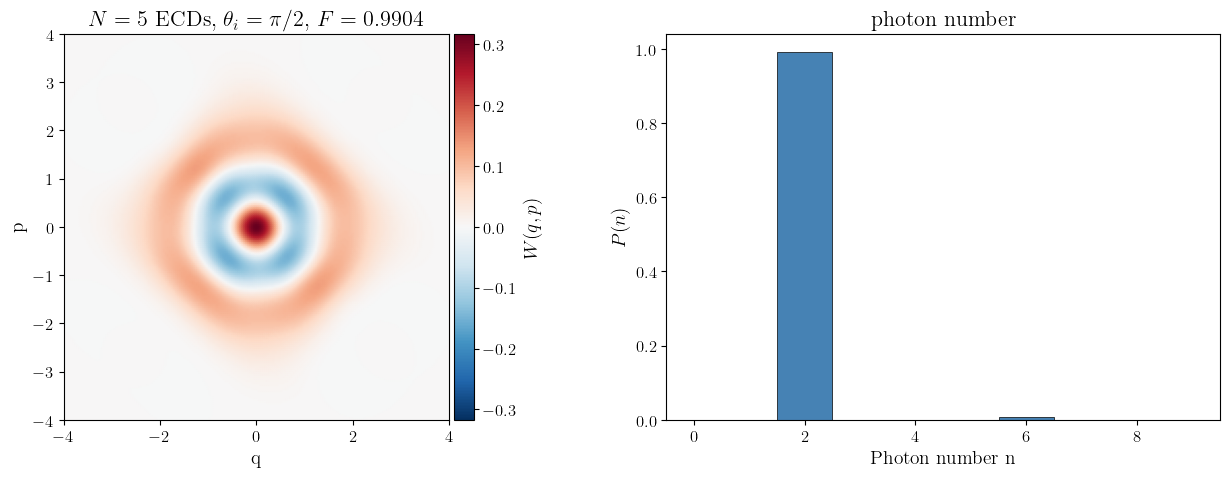

In [15]:
psi_prepared = to_qarray(result.final_ket()).unit()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_wigner(
    psi_prepared,
    x_bound=4.0,
    y_bound=4.0,
    ax=axes[0],
    title=rf"$N = {n_gates}$ ECDs, $\theta_i = \pi/2$, $F = {result.fidelity:.4f}$",
)
plot_photon_number(psi_prepared, ax=axes[1], max_n=10, title="photon number")
plt.tight_layout()
plt.show()

### Depth sweep

How the achievable fidelity grows with $N$, all with $\theta_i = \pi/2$. The two shallowest
depths have closed forms: a single coherent branch gives
$|\braket{2|\hat D(\alpha)|0}|^2 = e^{-|\alpha|^2}|\alpha|^4/2$, maximized at
$|\alpha|^2 = 2$, so $N = 1$ is capped at $F = 2e^{-2} \approx 0.2707$, and $N = 2$ reaches
exactly twice that, $F = 4e^{-2} \approx 0.5413$, with all four paths landing on
$|A_s| = \sqrt{2}$. Freezing the angles reproduces both caps to nine digits. Every row is
re-checked at `n_fock_check` so that a leaky solution cannot masquerade as a good one.

In [16]:
print(f"{'N':>3}  {'free params':>12}  {'F':>13}  {'F (checked)':>13}  {'max|beta|':>10}")
print("-" * 60)
sweep = {}
for n in (1, 2, 3, 4):
    res_n = optimize_ecd_fixed_theta(
        n, n_fock, fock_target,
        theta=theta_fixed,
        n_seeds=64,
        seed=0,
        init_disp_scale=0.8,
        verbose=False,
        **penalty_kw,
    )
    th_n = np.asarray(res_n.params["thetas"])
    ph_n = np.asarray(res_n.params["phis"])
    be_n = np.asarray(res_n.params["betas"])
    f_check = abs(ecd_propagate(th_n, ph_n, be_n, n_fock_check)[0][fock_target]) ** 2
    sweep[n] = (res_n.fidelity, f_check, float(np.abs(be_n).max()))
    print(f"{n:>3}  {3 * n + 1:>12}  {res_n.fidelity:>13.9f}  {f_check:>13.9f}  "
          f"{np.abs(be_n).max():>10.4f}")

print()
print(f"closed forms:  N=1 -> 2/e^2 = {2 * np.exp(-2.0):.9f}"
      f"    N=2 -> 4/e^2 = {4 * np.exp(-2.0):.9f}")

  N   free params              F    F (checked)   max|beta|
------------------------------------------------------------
  1             4    0.270670566    0.270670566      2.8284
  2             7    0.541341133    0.541341133      2.7726
  3            10    0.928658122    0.928658122      1.9716
  4            13    0.957141047    0.957141047      1.8087

closed forms:  N=1 -> 2/e^2 = 0.270670566    N=2 -> 4/e^2 = 0.541341133


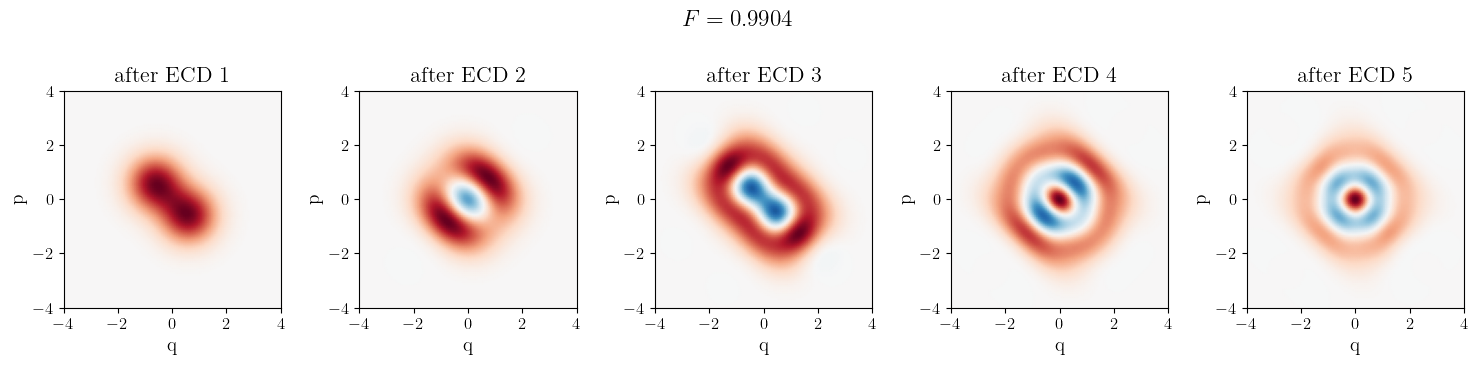

In [17]:
from gkp_optimal_control.gate_optimization import sequence_history
import numpy as np
import matplotlib.pyplot as plt

which = result          # or result_free
pair, bound, grid = 0, 4.0, 120

hist = sequence_history(which, vac)              # (2*n_gates+2, K, 2, n_fock)
ecd_idxs = range(2, 2 * which.n_gates + 1, 2)    # frame right after each ECD


def cavity_dm(frame):
    """Trace the qubit out of an ECD block state -> cavity density matrix."""
    f = np.asarray(frame)
    rho = np.outer(f[0], f[0].conj()) + np.outer(f[1], f[1].conj())
    return rho / np.real(np.trace(rho))


n_panels = which.n_gates
fig, axes = plt.subplots(1, n_panels, figsize=(3.0 * n_panels, 3.4))
for ax, i in zip(np.atleast_1d(axes), ecd_idxs):
    plot_wigner(state=cavity_dm(hist[i][pair]), x_bound=bound, y_bound=bound,
                ax=ax, title=f"after ECD {i // 2}", grid_points=grid,
                add_colorbar=False)
fig.suptitle(rf"$F = {which.fidelity:.4f}$", y=1.02)
fig.tight_layout()
plt.show()